Links:
 - https://stackoverflow.com/questions/78106951/how-do-i-access-input-devices-on-wsl2
 - https://www.pygame.org/docs/ref/midi.html

# Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sy
from scipy.signal import butter, lfilter
from scipy.io.wavfile import write
from IPython.display import Audio

In [3]:
def generate_triangle_wave():
    x, p = sy.symbols("x"), 2*sy.pi
    y = (4/p)*sy.Abs(sy.Mod(x - p/4, p) - p/2) - 1
    return sy.lambdify(x, y, "numpy")
triangle_wave = generate_triangle_wave()

def generate_sawtooth_wave():
    x, p = sy.symbols("x"), 2*sy.pi
    y = 2*(x/p - sy.floor(1/2 + x/p))
    return sy.lambdify(x, y, "numpy")
sawtooth_wave = generate_sawtooth_wave()

def generate_square_wave():
    x, p = sy.symbols("x"), 2*sy.pi
    y = (-1)**sy.floor(2*x/p)
    return sy.lambdify(x, y, "numpy")
square_wave = generate_square_wave()
# Add an option to vary the duty cycle. Could also add this to the other waveforms.

def generate_s_curve():
    x, y_start, y_end = sy.symbols("x, y_start, y_end")
    x_scaled = sy.sign(y_end - y_start)*(2*x - 1)
    y = -((x_scaled**3 - 3*x_scaled - 2)/4)*sy.Abs(y_end - y_start) + sy.Min(y_start, y_end)
    return sy.lambdify((x, y_start, y_end), y, "numpy")
s_curve = generate_s_curve()

def generate_attack():
    x, y_start = sy.symbols("x y_start")
    x_scaled = 2*x - 1
    y = -((x_scaled**3 - 3*x_scaled - 2)/4)*(1 - y_start) + y_start
    return sy.lambdify((x, y_start), y, "numpy")
attack_curve = generate_attack()

def generate_decay():
    x, sustain = sy.symbols("x sustain")
    x_scaled = -(2*x - 1)
    y = -((x_scaled**3 - 3*x_scaled - 2)/4)*(1 - sustain) + sustain
    return sy.lambdify((x, sustain), y, "numpy")
decay_curve = generate_decay()

def generate_release():
    x, sustain = sy.symbols("x sustain")
    x_scaled = -(2*x - 1)
    y = -((x_scaled**3 - 3*x_scaled - 2)/4)*sustain
    return sy.lambdify((x, sustain), y, "numpy")
release_curve = generate_release()

def generate_symbolic_adsr():
    x, attack_duration, decay_duration, sustain_duration, sustain_level, release_duration = sy.symbols("x attack_duration decay_duration sustain_duration sustain_level release_duration")
    attack_start, attack_end = 0, attack_duration
    decay_start, decay_end = attack_end, attack_end + decay_duration
    sustain_start, sustain_end, sustain = decay_end, decay_end + sustain_duration, sustain_level
    release_start, release_end = sustain_end, sustain_end + release_duration
    
    attack_condition = (attack_start < x) & (x <= attack_end)
    decay_condition = (decay_start < x) & (x <= decay_end)
    sustain_condition = (sustain_start < x) & (x <= sustain_end)
    release_condition = (release_start < x) & (x <= release_end)
    
    x_attack = 2*(x - attack_start)/(attack_end - attack_start) - 1
    attack = -(x_attack**3 - 3*x_attack - 2)/4
    
    x_decay = 2*(x - decay_start)/(decay_end - decay_start) - 1
    decay = -(((-x_decay)**3 - 3*(-x_decay) - 2)/4)*(1 - sustain) + sustain
    
    x_release = 2*(x - release_start)/(release_end - release_start) - 1
    release = -(((-x_release)**3 - 3*(-x_release) - 2)/4)*sustain
    
    y = sy.Piecewise((0, (x <= attack_start)), (attack, attack_condition), (decay, decay_condition), (sustain, sustain_condition), (release, release_condition), (0, (release_end < x)))
    return sy.lambdify((x, attack_duration, decay_duration, sustain_duration, sustain_level, release_duration), y, "numpy")
symbolic_adsr = generate_symbolic_adsr()
# This implementation of the ADSR is different from the standard implementation. 
# Normally, the attack_duration, decay_duration and release_duration would be defined in seconds, the attack then decay would trigger when the note is pressed, the sustain would continue while the note is held and the release would trigger when the note is released.
# You don't need to change the generate_symbolic_adsr function, just change the ADSR class below. Maybe add "ratio" and "durations" arguments so you can define it either way.
# Having the release continue after the note is released will require some more work. 

In [70]:
class Oscillator():
    def __init__(self, waveform = "sine", pitch = "C4", volume = 1, sample_rate = 44100):
        musical_alphabet = ["C", "C#/Db", "D", "Eb/D#", "E", "F", "F#/Gb", "G", "Ab/G#", "A", "Bb/A#", "B"]
        frequencies = [440*(2**((m - 69)/12)) for m in range(12, 120)]
        self.notes_lut = {}
        octaves = (np.floor(np.arange(12, 120)/12) - 1).astype(int)
        for index, (frequency, octave) in enumerate(zip(frequencies, octaves)):
            note = musical_alphabet[index%12] + str(octave)
            self.notes_lut[note] = frequency
        self.waveform = waveform
        self.pitch = pitch
        self.volume = volume
        self.sample_rate = sample_rate
    
    def generate_pitch(self, duration = None, samples = None):
        if duration and samples:
            raise Exception("Both duration and samples cannot be specified!")
        elif not duration and not samples:
            raise Exception("Either duration or samples must be specified!")
        elif duration:
            samples = int(self.sample_rate*duration)
        elif samples:
            duration = samples/self.sample_rate
        if self.pitch is None:
            return np.zeros(samples)
        else:
            return self.volume*self.waveform(np.linspace(0, self.pitch*duration*2*np.pi, samples))
    
    @property
    def pitch(self):
        return self._pitch
    @pitch.setter
    def pitch(self, pitch):
        if type(pitch) in [str, np.str_]:
            self._pitch = self.notes_lut[pitch.upper()]
        elif type(pitch) in [int, float]:
            self._pitch = pitch
        elif pitch is None:
            self._pitch = None
        else:
            raise Exception("Invalid pitch! Must be either a string, a number or None!")
    
    @property
    def waveform(self):
        return self._waveform
    @waveform.setter
    def waveform(self, waveform):
        if waveform == "sine":
            self._waveform = np.sin
        elif waveform == "triangle":
            self._waveform = triangle_wave
        elif waveform == "sawtooth":
            self._waveform = sawtooth_wave
        elif waveform == "square":
            self._waveform = square_wave
        else:
            raise Exception("Invalid waveform!, must be either 'sine', 'triangle', 'sawtooth' or 'square'!")

class ADSR():
    def __init__(self, attack = 0.25, decay = 0.25, sustain = 0.25, sustain_level = 0.5, release = 0.25):
        self.duration = attack + decay + sustain + release
        self.attack = attack/self.duration
        self.decay = decay/self.duration
        self.sustain = sustain/self.duration
        self.sustain_level = sustain_level
        self.release = release/self.duration
        self.adsr = self._generate_adsr()
        
    def _generate_adsr(self):
        def adsr(x):
            return symbolic_adsr(x, self.attack, self.decay, self.sustain, self.sustain_level, self.release)
        return adsr
    
    def apply(self, wave):
        return self.adsr(np.linspace(0, 1, wave.size))*wave

class Filter():
    def __init__(self, kernel_type = "low-pass", duration = 25e-3, width = 2, normalise = True, sample_rate = 44100):
        self.duration = duration
        self.width = width
        self.normalise = normalise
        self.sample_rate = sample_rate
        self.kernel_type = kernel_type
        self.kernel = self._kernel_low_pass()

    def _kernel_low_pass(self):
        def gaussian(x, sigma):
            return np.exp(-0.5*x**2/(sigma**2))
        width = self.width*2*np.pi
        samples = int(self.duration*self.sample_rate)
        domain = np.linspace(-width/2, width/2, samples)
        kernel = np.sinc(domain)*gaussian(domain, width/6)
        return kernel/np.abs(np.fft.fft(kernel)[0])
    
    def apply(self, wave):
        wave_filtered = np.convolve(wave, self.kernel, mode = "same")
        if self.normalise:
            wave_filtered -= wave_filtered.min()
            wave_filtered *= (wave.max() - wave.min())/wave_filtered.max()
            wave_filtered += wave.min()
        return wave_filtered

    @property
    def kernel_type(self):
        return self._kernel_type
    @kernel_type.setter
    def kernel_type(self, kernel_type):
        if kernel_type.lower() not in ["low-pass"]:
            raise Exception("Invalid kernel type! Must be either 'low-pass', some other type, another type, yet another, etc.!")
        self._kernel_type = kernel_type
        if hasattr(self, "kernel"):
            self.kernel = self._kernel_low_pass()
    
    @property
    def duration(self):
        return self._duration
    @duration.setter
    def duration(self, duration):
        self._duration = duration
        if hasattr(self, "kernel"):
            self.kernel = self._kernel_low_pass()
    
    @property
    def width(self):
        return self._width
    @width.setter
    def width(self, width):
        self._width = width
        if hasattr(self, "kernel"):
            self.kernel = self._kernel_low_pass()
    
    @property
    def sample_rate(self):
        return self._sample_rate
    @sample_rate.setter
    def sample_rate(self, sample_rate):
        self._sample_rate = sample_rate
        if hasattr(self, "kernel"):
            self.kernel = self._kernel_low_pass()

class Bar():
    def __init__(self, notes, note_values, time_signature = (4, 4)):
        self.notes = notes
        self.note_values = note_values
        self.time_signature = time_signature
        self._exception_check()
    
    def _exception_check(self):
        if np.array([True if hasattr(self, attribute) else False for attribute in ["notes", "note_values", "time_signature"]]).all():
            if self.notes.size != self.note_values.size:
                raise Exception("Number of notes must be equal to the number of note values!")
            elif self.notes.size < self.time_signature[0]:
                raise Exception("Too few notes in the bar!")
            elif self.notes.size > self.time_signature[0]:
                raise Exception("Too many notes in the bar!")
            elif self.note_values.sum() != self.time_signature[0]/self.time_signature[1]:
                raise Exception("Note values must sum to the length of the bar specified in the time signature!")
    
    @property
    def notes(self):
        return self._notes
    @notes.setter
    def notes(self, notes):
        self._notes = np.array(notes) if type(notes) != np.ndarray else notes
        self._exception_check()
    
    @property
    def note_values(self):
        return self._note_values
    @note_values.setter
    def note_values(self, note_values):
        self._note_values = np.array(note_values) if type(note_values) != np.ndarray else note_values
        self._exception_check()

def calculate_note_sample_masks(bar, bpm, sample_rate = 44100):
    bar_duration = bar.time_signature[0]*60/bpm
    bar_samples = int(bar_duration*sample_rate)
    beat_samples = bar_samples*bar.time_signature[1]/bar.time_signature[0]
    note_sample_mask = np.full((bar.notes.size, bar_samples), False)
    for index, note_value in enumerate(bar.note_values):
        mask_start = np.floor(bar.note_values[:index].sum()*beat_samples).astype(int)
        mask_end = mask_start + np.floor(note_value*beat_samples).astype(int)
        note_sample_mask[index, mask_start:mask_end] = True
    return note_sample_mask

def generate_wave(bar, oscillators, adsrs, filters, bpm, sample_rate = 44100):
    if type(oscillators) not in [list, tuple]:
        oscillators = [oscillators for _ in range(bar.notes.size)]
    if type(adsrs) not in [list, tuple]:
        adsrs = [adsrs for _ in range(bar.notes.size)]
    if type(filters) not in [list, tuple]:
        filters = [filters for _ in range(bar.notes.size)]
    note_sample_masks = calculate_note_sample_masks(bar, bpm, sample_rate = sample_rate)
    waves = np.zeros(note_sample_masks.shape)
    for index, note_sample_mask in enumerate(note_sample_masks):
        note_samples = note_sample_mask.sum()
        if oscillators[index] is not None:
            oscillators[index].pitch = bar.notes[index]
            wave = oscillators[index].generate_pitch(samples = note_samples)
        else:
            wave = np.zeros(note_samples)
        if adsrs[index] is not None:
            wave = adsrs[index].apply(wave)
        if filters[index] is not None:
            wave = filters[index].apply(wave)
        waves[index][note_sample_mask] = wave
    return waves.sum(0)

def generate_pause(value, time_signature, bpm, sample_rate = 44100):
    duration = value*time_signature[1]*60/bpm
    samples = int(duration*sample_rate)
    return np.zeros(samples)

def normalise(array_input, new_min = 0, new_max = 1):
    array_output = array_input - array_input.min()
    array_output *= (new_max - new_min)/np.ptp(array_output)
    array_output += new_min
    return array_output

def mix(waves, volumes, output_volume = 1):
    waves = np.array(waves) if type(waves) != np.ndarray else waves
    if waves.ndim == 2:
        wave_output = np.array([normalise(wave, -volume, volume) for wave, volume in zip(waves, volumes)]).sum(0)
    elif waves.ndim == 1:
        wave_output = normalise(waves, -volumes, volumes)
    else:
        raise Exception("waves must be either 1-dimensional or 2-dimensional.")
    return normalise(wave_output, -output_volume, output_volume)

def save(file_name, array_input, bit_depth = 32, sample_rate = 44100):
    array_output = normalise(array_input, -2**bit_depth/2, 2**bit_depth/2 - 1)*np.ptp(array_input)/2
    if array_output.ndim == 1:
        array_output = np.expand_dims(array_output, 1)
    elif array_output.ndim == 2:
        array_output = np.swapaxes(array_output, 0, 1)
    if bit_depth == 32:
        array_output = array_output.astype(np.int32)
    elif bit_depth == 16:
        array_output = array_output.astype(np.int16)
    file_name = file_name + ".wav" if file_name[-4:] != ".wav" else file_name
    write(file_name, sample_rate, array_output)
# write can take a stack of wave arrays and play them together, avoiding the clipping issue when waves are summed. This also means the oscillator's volume parameter actually does something.
# Could make a mixer function that takes a bunch of waves as input and combines them while maintaining their volumes.

In [772]:
musical_alphabet = [["C"], ["C#", "Db"], ["D"], ["Eb", "D#"], ["E"], ["F"], ["F#", "Gb"], ["G"], ["Ab", "G#"], ["A"], ["Bb", "A#"], ["B"]]
frequencies = [440*(2**((m - 69)/12)) for m in range(12, 120)]
notes_lut = {}
octaves = (np.floor(np.arange(12, 120)/12) - 1).astype(int)
for index, (frequency, octave) in enumerate(zip(frequencies, octaves)):
    for note in musical_alphabet[index%12]:
        notes_lut[note + str(octave)] = frequency
    
class Clock():
    def __init__(self, bpm = 120, sample_rate = 44100):
        self._initialised = False
        self.bpm = bpm
        self.sample_rate = sample_rate
        self.time = 0
        self.tick_index = 0
        self._observers = []
        self._initialised = True
    
    def attach(self, observer):
        self._observers.append(observer)
    
    def _notify_observers(self, notifications):
        if len(self._observers):
            for observer in self._observers:
                observer.update(self, notifications)
    
    def tick(self):
        self.time += self.sample_interval
        self.tick_index += 1
        self._notify_observers(["tick"])
    
    @property
    def bpm(self):
        return self._bpm
    @bpm.setter
    def bpm(self, value):
        self._bpm = value
        self.beat_interval = 60/self._bpm
        if self._initialised:
            self._notify_observers(["bpm", "beat_interval"])
    
    @property
    def sample_rate(self):
        return self._sample_rate
    @sample_rate.setter
    def sample_rate(self, value):
        self._sample_rate = value
        self.sample_interval = 1/self._sample_rate # Make this its own property instead? 
        if self._initialised:
            self._notify_observers(["sample_rate", "sample_interval"])

class Oscillator():
    def __init__(self, clock, waveform = "sine", frequency = 440, frequency_ramp_rate = None):
        self._initialised = False
        self.clock = clock
        self.clock.attach(self)
        self.waveform = waveform
        self.frequency_ramp_rate = self.clock.sample_rate/2 if frequency_ramp_rate is None else frequency_ramp_rate
        self.frequency_ramp = None
        self.frequency = frequency
        self.phase = 0
        self._initialised = True
    
    def update(self, subject, notifications):
        if subject == self.clock:
            if "tick" in notifications:
                if self.frequency_ramp is not None:
                    index = self.clock.tick_index - self.frequency_ramp_index
                    if index < self.frequency_ramp.size:
                        self._frequency = self.frequency_ramp[index]
                    else:
                        self.frequency_ramp = None
    
    @property
    def value(self):
        if self.frequency is None:
            return None
        self.phase += 2*np.pi*self._frequency/self.clock.sample_rate
        self.phase %= 2*np.pi
        return self.waveform(self.phase)
    
    @property
    def frequency(self):
        return self._frequency
    @frequency.setter
    def frequency(self, value):
        frequency_previous = self._frequency if hasattr(self, "_frequency") else 0
        if type(value) in [str, np.str_]:
            self._frequency = notes_lut[value.upper()]
        elif type(value) in [int, float, np.float64]:
            self._frequency = value
        elif value is None:
            self._frequency = None
        else:
            raise Exception("Invalid frequency! Must be either a string, a number or None!")
        if self._initialised:
            if self.frequency_ramp is not None:
                pass
            elif self.frequency_ramp is None:
                frequency_ramp_samples = int(np.abs(self._frequency - frequency_previous)*self.clock.sample_rate/self.frequency_ramp_rate)
                self.frequency_ramp = s_curve(np.linspace(0, 1, frequency_ramp_samples), frequency_previous, self._frequency)
                self.frequency_ramp_index = self.clock.tick_index
    
    @property
    def waveform(self):
        return self._waveform
    @waveform.setter
    def waveform(self, value):
        if value == "sine":
            self._waveform = np.sin
        elif value == "triangle":
            self._waveform = triangle_wave
        elif value == "sawtooth":
            self._waveform = sawtooth_wave
        elif value == "square":
            self._waveform = square_wave
        elif callable(value):
            self._waveform = value
        else:
            raise Exception("Invalid waveform!, must be either 'sine', 'triangle', 'sawtooth', 'square' or a periodic function with period = 2*pi!") 

class ADSR():
    def __init__(self, clock, attack_duration = 25e-3, decay_duration = 25e-3, sustain_level = 0.5, release_duration = 25e-3):
        self._initialised = False
        self.phase = None
        self.clock = clock
        self.clock.attach(self)
        # self.input_device = input_device
        # self.input_device.attach(self)
        self.active = False
        self.attack_duration = attack_duration
        self.decay_duration = decay_duration
        self.sustain_level = sustain_level
        self.release_duration = release_duration
        self._generate_adsr()
        self._initialised = True
    
    def update(self, subject, notifications):
        if subject == self.clock:
            if self.phase is not None and "tick" in notifications:
                if self.phase == "attack":
                    index = self.clock.tick_index - self._attack_index - 1
                    if index < self.attack.size:
                        self.value = self.attack[index]
                    else:
                        self.phase = "decay"
                elif self.phase == "decay":
                    index = self.clock.tick_index - self._decay_index - 1
                    if index < self.decay.size:
                        self.value = self.decay[index]
                    else:
                        self.phase = "sustain"
                elif self.phase == "sustain":
                    self.value = self.sustain_level
                elif self.phase == "release":
                    index = self.clock.tick_index - self._release_index - 1
                    if index == 0 and self.value != self.sustain_level:
                        self.release = release_curve(np.linspace(0, 1, self.release_samples), self.value)
                    if index < self.release.size:
                        self.value = self.release[index]
                    else:
                        self.value = 0
                        self.phase = None
            if "sample_rate" in notifications:
                self._generate_adsr()     
    
    def _generate_adsr(self):
        self.attack = attack_curve(np.linspace(0, 1, self.attack_samples), 0)
        self.decay = decay_curve(np.linspace(0, 1, self.decay_samples), self.sustain_level)
        self.release = release_curve(np.linspace(0, 1, self.release_samples), self.sustain_level)
    
    @property
    def active(self):
        return self._active
    @active.setter
    def active(self, value):
        self._active = value
        if self._initialised:
            if self.active:
                if self.phase == "release":
                    self.attack = attack_curve(np.linspace(0, 1, self.attack_samples), self.value)
                self.phase = "attack"
                self._attack_index = self.clock.tick_index
                self._decay_index = self._attack_index + self.attack.size
                self._sustain_index = self._decay_index + self.decay.size
            elif not self.active:
                self.phase = "release"
                self._release_index = self.clock.tick_index 
    
    @property
    def phase(self):
        return self._phase
    @phase.setter
    def phase(self, value):
        self._phase = value
        if self._phase is None:
            self.value = 0
    
    @property
    def attack_duration(self):
        return self._attack_duration
    @attack_duration.setter
    def attack_duration(self, value):
        self._attack_duration = value
        if self._initialised:
            self._generate_adsr()
    
    @property
    def decay_duration(self):
        return self._decay_duration
    @decay_duration.setter
    def decay_duration(self, value):
        self._decay_duration = value
        if self._initialised:
            self._generate_adsr()
    
    @property
    def sustain_level(self):
        return self._sustain_level
    @sustain_level.setter
    def sustain_level(self, value):
        self._sustain_level = value
        if self._initialised:
            self._generate_adsr()
    
    @property
    def release_duration(self):
        return self._release_duration
    @release_duration.setter
    def release_duration(self, value):
        self._release_duration = value
        if self._initialised:
            self._generate_adsr()
    
    @property
    def attack_samples(self):
        return int(self.attack_duration*self.clock.sample_rate)
    
    @property
    def decay_samples(self):
        return int(self.decay_duration*self.clock.sample_rate)
    
    @property
    def release_samples(self):
        return int(self.release_duration*self.clock.sample_rate)

class Filter():
    def __init__(self, clock, mode = "low-pass", cutoff_frequency = 440):
        self._initialised = False
        self.clock = clock
        self.clock.attach(self)
        self.mode = mode
        self.cutoff_frequency = cutoff_frequency
        self._generate_filter()
        self._initialised = True

    def update(self, subject, notifications):
        if subject == self.clock:
            if "sample_rate" in notifications:
                self._generate_filter()
    
    def _generate_filter(self):
        if self.mode == "low-pass":
            order = 2
            threshold = 0.01
            self.filter_coefficients = butter(order, self.cutoff_frequency, btype = "lowpass", fs = self.clock.sample_rate)
            impulse = np.zeros(int(self.clock.sample_rate*order*2/self.cutoff_frequency))
            impulse[0] = 1
            self.impulse_response = lfilter(*self.filter_coefficients, impulse)
            self.buffer_samples = self.impulse_response.size - np.argwhere(np.abs(self.impulse_response)[::-1] > threshold*self.impulse_response.max())[0, 0]
            # self.buffer_samples = int(self.clock.sample_rate*order/self.cutoff_frequency)
            
    def __call__(self, value):
        self.buffer[-1] = value
        value_filtered = lfilter(*self.filter_coefficients, self.buffer)[-1]
        self.buffer[:-1] = self.buffer[1:]
        return value_filtered
    
    @property
    def mode(self):
        return self._mode
    @mode.setter
    def mode(self, value):
        self._mode = value
        if self._initialised:
            self._generate_filter()
    
    @property
    def cutoff_frequency(self):
        return self._cutoff_frequency
    @cutoff_frequency.setter
    def cutoff_frequency(self, value):
        self._cutoff_frequency = value
        if self._initialised:
            self._generate_filter()
    
    @property
    def buffer_samples(self):
        return self._buffer_samples
    @buffer_samples.setter
    def buffer_samples(self, value):
        self._buffer_samples = value
        if self._initialised:
            if self._buffer_samples > self.buffer.size:
                self.buffer = np.pad(self.buffer, ((self._buffer_samples - self.buffer.size, 0)))
            elif self._buffer_samples < self.buffer.size:
                self.buffer = self.buffer[self.buffer.size - self._buffer_samples:]
        elif not self._initialised:
            self.buffer = np.zeros(self._buffer_samples)        

class Voice:
    def __init__(self, clock, objects, waveform_function, frequency_function, activation_function):
        self._initialised = False
        self.clock = clock
        self.clock.attach(self)
        self.objects = objects
        self.waveform_function = waveform_function
        self.frequency_function = frequency_function
        self.activation_function = activation_function
        self._value = 0
        self._frequency = 0
        self._active = False
        self._initialised = True

    def update(self, subject, notifications):
        if subject == self.clock:
            if "tick" in notifications:
                self._value = self.waveform_function(self)
    
    @property
    def value(self):
        return self._value

    @property
    def frequency(self):
        return self._frequency
    @frequency.setter
    def frequency(self, value):
        if self._initialised:
            self._frequency = value
            self.frequency_function(self, self._frequency)

    @property
    def active(self):
        return self._active
    @active.setter
    def active(self, value):
        if self._initialised:
            self._active = value
            self.activation_function(self, self._active)

class Note():
    def __init__(self, frequency, value, hold_duration, volume = 1):
        self.frequency = frequency
        self.value = np.array(value).sum() if type(value) in [tuple, list] else value
        self.hold_duration = hold_duration
        self.volume = volume
    
    # Allow frequency and volume to be controlled by an envelope
    
    @property
    def frequency(self):
        return self._frequency
    @frequency.setter
    def frequency(self, value):
        if type(value) in [str, np.str_]:
            self._frequency = notes_lut[value]
        elif type(value) in [int, float, np.float64]:
            self._frequency = value
        elif value is None:
            self._frequency = 0
        else:
            raise Exception("Invalid frequency! Must be either a string, a number or None!")

class Bar():
    def __init__(self, clock, voice, time_signature, notes = None):
        self._initialised = False
        self.clock = clock
        self.voice = voice
        self.notes = notes
        self.time_signature = time_signature
        self._generate_wave()
        self._initialised = True
    
    # Include the duration of each note, no. samples, etc
    
    def _generate_wave(self):
        # if len(self.notes) < self.time_signature[0]:
        #     raise Exception("Too few notes in the bar!")
        # elif len(self.notes) > self.time_signature[0]:
        #     raise Exception("Too many notes in the bar!")
        # elif np.array([note.value for note in self.notes]).sum() != self.time_signature[0]/self.time_signature[1]:
        #     raise Exception("Note values must sum to the length of the bar specified in the time signature!")
        self.duration = self.clock.beat_interval*np.array([note.value*4 for note in self.notes]).sum()
        self.samples = int(self.clock.sample_rate*self.duration)
        self.wave = np.zeros(self.samples)
        index_start = self.clock.tick_index
        for note in self.notes:
            self.voice.frequency = note.frequency
            note_samples = int(note.value*4*self.clock.beat_interval*self.clock.sample_rate)
            hold_end = int(note.hold_duration*self.clock.sample_rate)
            self.voice.active = True
            for index in range(note_samples):
                if index == hold_end:
                    self.voice.active = False
                self.wave[self.clock.tick_index - index_start] = self.voice.value
                self.clock.tick()
    
    @property
    def notes(self):
        return self._notes
    @notes.setter
    def notes(self, value):
        self._notes = value
        if self._initialised:
            self._generate_wave()
    
    @property
    def time_signature(self):
        return self._time_signature
    @time_signature.setter
    def time_signature(self, value):
        if value is None:
            self._time_signature = (len(self.notes), len(self.notes)/np.array([note.value for note in self.notes]).sum())
        else:
            self._time_signature = value
        if self._initialised:
            self._generate_wave()

def normalise(array_input, new_min = 0, new_max = 1):
    array_output = array_input - array_input.min()
    array_output *= (new_max - new_min)/np.ptp(array_output)
    array_output += new_min
    return array_output

def mix(waves, volumes, output_volume = 1):
    waves = np.array(waves) if type(waves) != np.ndarray else waves
    if waves.ndim == 2:
        wave_output = np.array([normalise(wave, -volume, volume) for wave, volume in zip(waves, volumes)]).sum(0)
    elif waves.ndim == 1:
        wave_output = normalise(waves, -volumes, volumes)
    else:
        raise Exception("waves must be either 1-dimensional or 2-dimensional.")
    wave_output = normalise(wave_output, -output_volume, output_volume)
    return wave_output - wave_output.mean()

def save(file_name, array_input, bit_depth = 32, sample_rate = 44100):
    array_output = normalise(array_input, -2**bit_depth/2, 2**bit_depth/2 - 1)*np.ptp(array_input)/2
    if array_output.ndim == 1:
        array_output = np.expand_dims(array_output, 1)
    elif array_output.ndim == 2:
        array_output = np.swapaxes(array_output, 0, 1)
    if bit_depth == 32:
        array_output = array_output.astype(np.int32)
    elif bit_depth == 16:
        array_output = array_output.astype(np.int16)
    file_name = file_name + ".wav" if file_name[-4:] != ".wav" else file_name
    write(file_name, sample_rate, array_output)
# write can take a stack of wave arrays and play them together, avoiding the clipping issue when waves are summed. This also means the oscillator's volume parameter actually does something.
# Could make a mixer function that takes a bunch of waves as input and combines them while maintaining their volumes.

# Test 

In [510]:
def calculate_slopes(x, y):
    # Assuming input function is periodic.
    slopes = np.diff(y, append = y[1])/np.diff(x, append = x[-1] + x[1])
    return slopes

def linear_interpolation(x, y, slopes, x_new):
    # ceiling_index = np.searchsorted(x, x_new, side = "left")
    floor_index = np.searchsorted(x, x_new, side = "right") - 1
    y_floor, x_floor = y[floor_index], x[floor_index]
    y_new = y_floor + (x_new - x_floor)*slopes[floor_index]
    return y_new

def lut_floor(x_lut, y_lut, x):
    floor_index = np.searchsorted(x_lut, x, side = "right") - 1
    return y_lut[floor_index]

x_sin_lut = np.linspace(0, 2*np.pi, 44100)
y_sin_lut = np.sin(x_sin_lut)
s_sin_lut = calculate_slopes(x_sin_lut, y_sin_lut)

duration = 1
frequencies = np.random.uniform(430, 450, 300)
frequencies = np.array([10, 20])
phase_offsets = np.random.uniform(-np.pi, np.pi, frequencies.size)
samples = int(44100*duration)
wave_0 = np.zeros(samples)

sample_points = np.linspace(0, 2*np.pi, wave_0.size)
for index, sample_point in enumerate(sample_points):
    phases = (frequencies*sample_point)%(2*np.pi)
    floor_indices = np.searchsorted(x_sin_lut, phases, side = "right") - 1
    y_floor = y_sin_lut[floor_indices]
    x_floor = x_sin_lut[floor_indices]
    slopes = s_sin_lut[floor_indices]
    wave_0[index] = np.sum(y_floor + (phases - x_floor)*slopes)

In [782]:
class Oscillator_Bank():
    def __init__(self, clock, waveform, frequencies, amplitudes = None, phases = None):
        self._initialised = False
        self.clock = clock
        self.clock.attach(self)
        self.waveform = waveform
        self.frequencies = frequencies
        self.amplitudes = np.ones_like(self.frequencies) if amplitudes is None else amplitudes
        self.phases = np.linspace(0, 2*np.pi, self.frequencies.size, endpoint = False) if phases is None else phases
        self._value = 0
        self._initialised = True
    
    def update(self, subject, notifications):
        if subject == self.clock:
            if "tick" in notifications:
                self._value = np.sum(self.amplitudes*self._waveform(self.frequencies*(2*np.pi*self.clock.time - self.phases)))
    
    @property
    def value(self):
        return self._value
    
    @property
    def frequencies(self):
        return self._frequencies
    @frequencies.setter
    def frequencies(self, value):
        if type(value) in [list, tuple]:
            self._frequencies = np.zeros(len(value))
            for index, frequency in enumerate(value):
                self._frequencies[index] = notes_lut[frequency] if type(frequency) == str else frequency
        elif type(value) == np.ndarray:
            if value.dtype.type == np.str_:
                self._frequencies = np.array([notes_lut[frequency] for frequency in value])
            else: self._frequencies = value
        self._frequencies = self._frequencies.astype(float)
    
    @property
    def waveform(self):
        return self._waveform
    @waveform.setter
    def waveform(self, value):
        if value == "sine":
            self._waveform = np.sin
        elif value == "triangle":
            self._waveform = triangle_wave
        elif value == "sawtooth":
            self._waveform = sawtooth_wave
        elif value == "square":
            self._waveform = square_wave
        elif callable(value):
            self._waveform = value
        else:
            raise Exception("Invalid waveform!, must be either 'sine', 'triangle', 'sawtooth', 'square' or a periodic function with period = 2*pi!") 

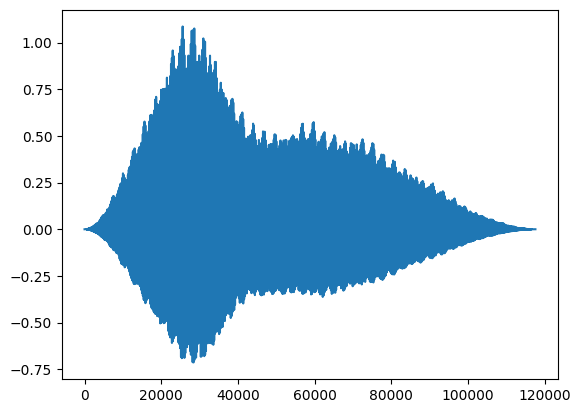

In [797]:
clock = Clock(120, 44100//3)
# frequencies = np.concatenate([np.linspace(440*0.95, 440, 8, endpoint = False), np.linspace(440, 440*1.05, 8)])
# amplitudes = np.concatenate([np.linspace(0, 1, frequencies.size//2, endpoint = False), np.linspace(1, 0, frequencies.size//2 + frequencies.size%2)])**2
frequencies = np.array(["C4", "E4", "G4", "B5"])
amplitudes = 2.0**-np.arange(frequencies.size)
# frequencies = np.array(["A4"])
# amplitudes = np.array([1])
oscillator_bank = Oscillator_Bank(clock, "sawtooth", frequencies, amplitudes)
lpf = Filter(clock, "low-pass", notes_lut["C4"])
adsr = ADSR(clock, 2, 1, 0.5, 4)
wave = np.zeros(8*clock.sample_rate)
adsr.active = True
for index in range(wave.size):
    if index == int(4*clock.sample_rate):
        adsr.active = False
    wave[index] = lpf(oscillator_bank.value)*adsr.value
    clock.tick()
wave = mix(wave, 1, 0.9)
plt.plot(wave)
save("test", wave, 16, clock.sample_rate)
Audio("test.wav")

In [727]:
frequencies.max() - phases[-1]

875.2876110196153

In [745]:
p_0 = 1/frequencies[0] + 1/frequencies[0]*2*np.pi/phases[0]
p_1 = 1/frequencies[1] + 1/frequencies[1]*2*np.pi/phases[1]
p_2 = 1/frequencies[2] + 1/frequencies[2]*2*np.pi/phases[2]

print(p_0, p_1, p_2)

inf 0.008522727272727274 0.004090909090909091


/tmp/ipykernel_1722/2495336529.py:1: RuntimeWarning: divide by zero encountered in scalar divide
  p_0 = 1/frequencies[0] + 1/frequencies[0]*2*np.pi/phases[0]


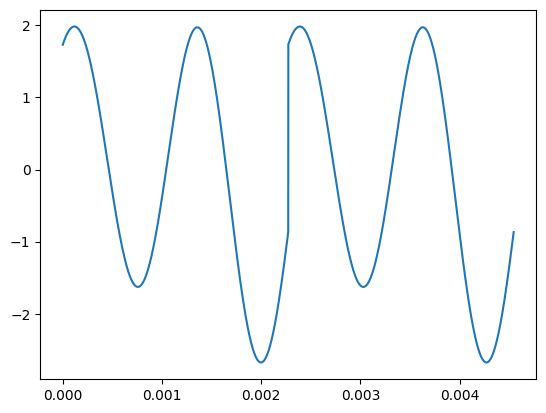

In [742]:
frequencies = np.linspace(440, 880, 4)
phases = np.linspace(0, 2*np.pi, frequencies.size, endpoint = False)
# phases = np.zeros(frequencies.size)
times = np.linspace(0, 1/frequencies.min(), 44100)
sin_luts = np.array([np.sin(frequency*(2*np.pi*times - phase)) for frequency, phase in zip(frequencies, phases)])
# for s in sin_luts:
#     plt.plot(times, s)
# # plt.plot(times, sin_luts.sum(0))
plt.plot(np.concatenate([times, times + times.max()]), np.concatenate([sin_luts.sum(0)]*2))
# wave = mix(np.concatenate([sin_luts.sum(0)]*100), 1, 0.9)
# plt.plot(wave)
# save("test", wave, 16)
# Audio("test.wav")

In [739]:
2*np.pi/(frequencies.max() + phases.max())

0.007101952437244431

In [722]:
2*np.pi/0.007

897.5979010256551

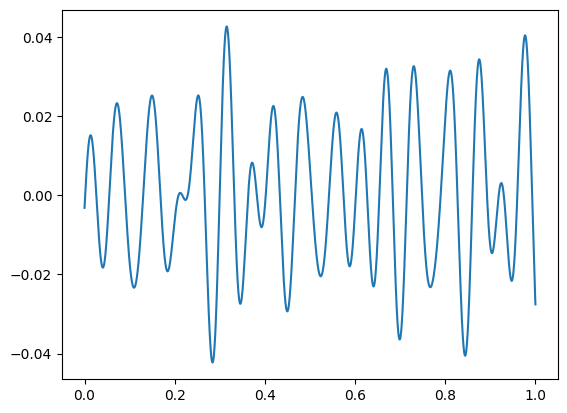

In [561]:
duration = 1
frequencies = np.random.uniform(10, 20, 300)
# frequencies = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
phase_offsets = np.random.uniform(-np.pi, np.pi, frequencies.size)
amplitudes = np.linspace(1, 0, frequencies.size)
samples = int(44100*duration)
times = np.linspace(0, duration, samples)
wave = np.zeros(samples)
for index, time in enumerate(times):
    phases = frequencies*2*np.pi*time + phase_offsets
    wave[index] = np.sum(amplitudes*np.sin(phases))
wave /= frequencies.size
plt.plot(sample_points, wave)

In [454]:
sample_points = np.linspace(0, 2*np.pi, wave_1.size)
for index, sample_point in enumerate(sample_points):
    for frequency in frequencies:
        wave_1[index] += np.sin(frequency*sample_point)

In [441]:
sample_points = np.linspace(0, 2*np.pi, wave_2.size)
for index, sample_point in enumerate(sample_points):
    for frequency in frequencies:
        wave_2[index] += lut_floor(x_sin_lut, y_sin_lut, (frequency*sample_point)%(2*np.pi))

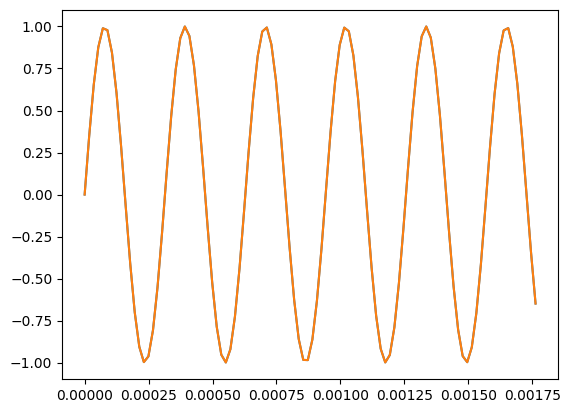

In [434]:
# plt.plot(x_sin_lut, y_sin_lut)
plt.plot(sample_points[:100], wave_0[:100])
plt.plot(sample_points[:100], wave_1[:100])
plt.show()

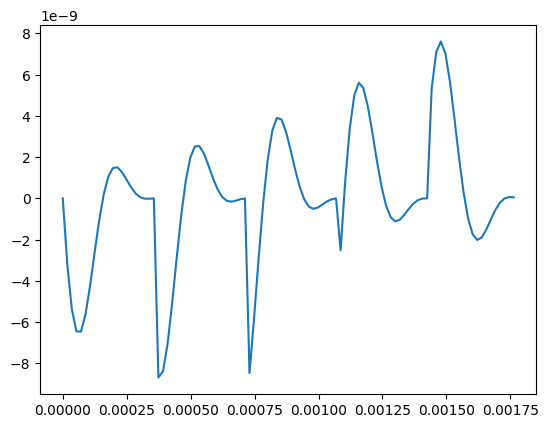

In [429]:
plt.plot(sample_points[:100], (np.sin(frequency*sample_points) - wave)[:100])

[0.         0.11111111 0.22222222 0.33333333 0.44444444 0.55555556
 0.66666667 0.77777778 0.88888889 1.        ]
[ True  True  True False False False False False False False]
2 3
0.2222222222222222 0.3333333333333333
0.04938271604938271 0.1111111111111111
0.09259259259259259


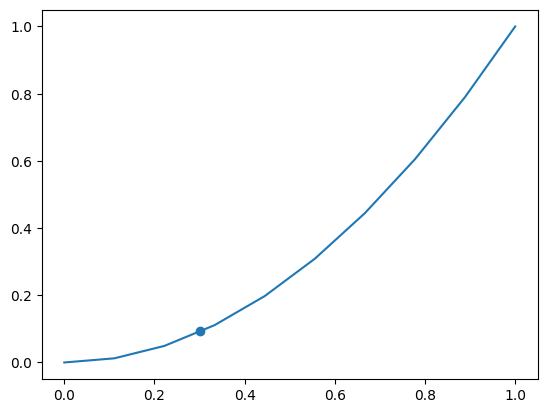

In [375]:
x = np.linspace(0, 1, 10)
y = x**2
print(x)
x_new = 0.3
print(x < x_new)
ceiling_index = np.sum(x < x_new)
floor_index = ceiling_index - 1
print(floor_index, ceiling_index)
print(x[floor_index], x[ceiling_index])
print(y[floor_index], y[ceiling_index])
y_new = y[floor_index] + (y[ceiling_index] - y[floor_index])*((x_new - x[floor_index])/(x[ceiling_index] - x[floor_index]))
print(y_new)

plt.plot(x, y)
plt.scatter(x_new, y_new)

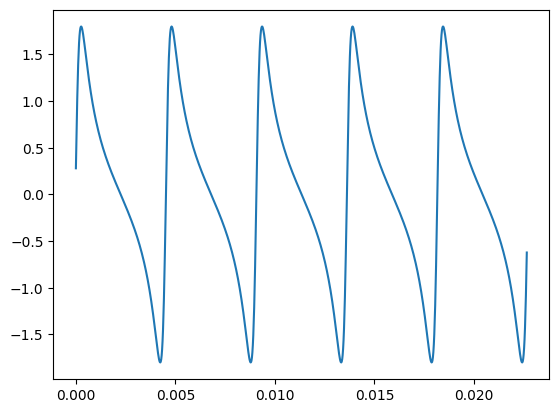

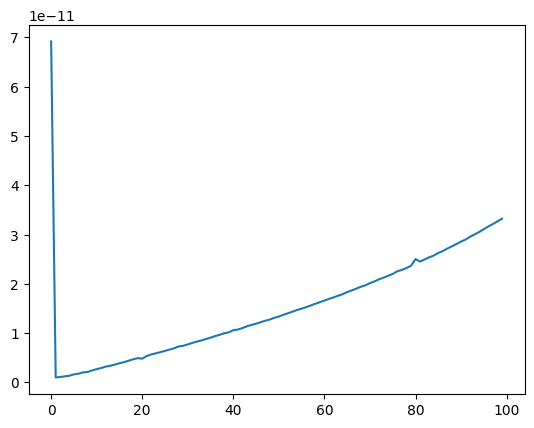

In [364]:
signal = np.zeros(1*44100)
clock = Clock()
# oscillator = Oscillator(clock, frequency = 100, frequency_ramp_rate = 44100/4)
# oscillator_2 = Oscillator(clock, frequency = 400, frequency_ramp_rate = 44100/4)
oscillators = np.array([Oscillator(clock, "sine", frequency) for frequency in np.arange(1, 32)*440/2])
scales = 1.5**-np.arange(oscillators.size)
for i in range(signal.size):
    clock.tick()
    for index, oscillator in enumerate(oscillators):
        signal[i] += oscillator.value*scales[index]
# cycles per sample
x = np.arange(signal.size)*clock.sample_interval
plt.figure()
plt.plot(x[:1000], signal[:1000])
plt.figure()
plt.plot(np.linspace(0, clock.sample_rate, signal.size)[:100], np.abs(np.fft.fft(signal))[:100])

wave = mix(signal, 1, 0.9)
save("test", wave, 16)
Audio("test.wav")


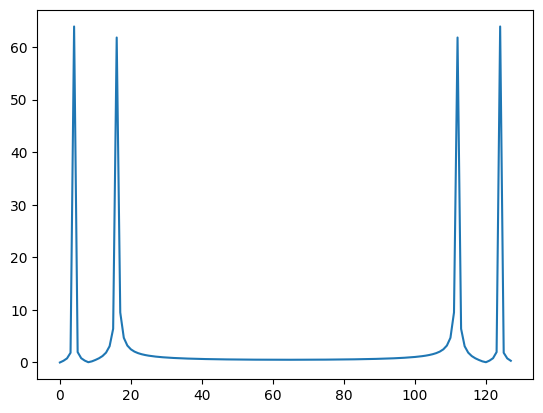

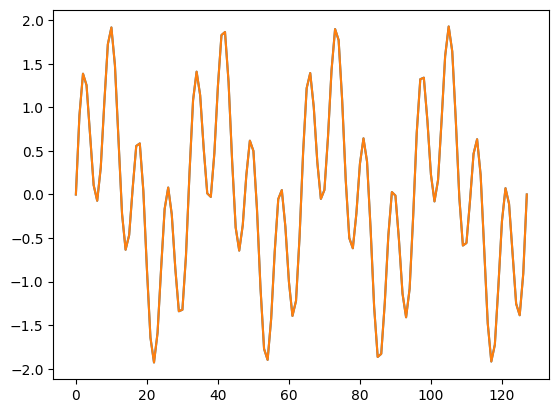

In [326]:
sample_rate = 128
f = np.sin(4*np.linspace(0, 2*np.pi, sample_rate)) + np.sin(16*np.linspace(0, 2*np.pi, sample_rate))# + np.sin(16*np.linspace(0, 2*np.pi, sample_rate))
f_fft = np.fft.fft(f)
# f_fft /= f_fft.size
# f_fft[16] = 2*np.pi + sample_rate/2j
# f_fft[-16] = 2*np.pi + sample_rate/2j
# f_fft *= f_fft.size

wave = np.real(np.fft.ifft(f_fft))
plt.figure()
plt.plot(np.abs(f_fft))
plt.figure()
plt.plot(f)
plt.plot(wave)

In [362]:
clock = Clock(45, 44100)
oscillators = np.array([Oscillator(clock, "sawtooth", 440) for _ in range(8)])
lfo = Oscillator(clock, "sine", 20)
low_pass_filter = Filter(clock, "low-pass", notes_lut["E5"])
adsr = ADSR(clock, 50e-3, 150e-3, 0.75, 300e-3)
    
objects = [oscillators, low_pass_filter, adsr, lfo]
def waveform_function(self):
    value = np.array([oscillator.value for oscillator in self.objects[0]]).sum()
    output = self.objects[1](value)*self.objects[2].value
    return output
def frequency_function(self, frequency):
    self.objects[1].frequency = frequency
    for index, oscillator in enumerate(self.objects[0]):
        oscillator.frequency = frequency*np.random.uniform(1.49, 1.51)**-index
def activation_function(self, activation):
    self.objects[2].active = activation
voice = Voice(clock, objects, waveform_function, frequency_function, activation_function)
notes = [Note("C5", 1/4, 1),
         Note("Bb4", 1/8, 1),
         Note("Ab4", 1/8, 1),
         Note("G4", 1/4, 1)]#,
        #  Note(None, 1/4, 0.5),
        #  Note("C5", 1/4, 0.5),
        #  Note("Bb4", 1/8, 0.25),
        #  Note("Ab4", 1/8, 0.25),
        #  Note("G4", 1/4, 0.5),]
bar = Bar(clock, voice, None, notes)
wave = mix(bar.wave, 1, 0.8)

save("test", wave, 16, clock.sample_rate)
Audio("test.wav")

In [172]:
clock = Clock(60, 44100)
oscillator = Oscillator(clock, "triangle", 440)
lfo = Oscillator(clock, "sine", 20)
low_pass_filter = Filter(clock, "low-pass", notes_lut["E5"])
adsr = ADSR(clock, 350e-3, 150e-3, 0.75, 500e-3)
    
objects = [oscillator, low_pass_filter, adsr, lfo]
def waveform_function(self):
    original_frequency = self.objects[0].frequency
    self.objects[0].frequency = original_frequency*(1 + self.objects[3].value*0.1)
    output = self.objects[1](self.objects[0].value)*self.objects[2].value
    self.objects[0].frequency = original_frequency
    return output
def frequency_function(self, frequency):
    self.objects[0].frequency = frequency
def activation_function(self, activation):
    self.objects[2].active = activation
voice = Voice(clock, objects, waveform_function, frequency_function, activation_function)
notes = [Note("D5", 1/4, 0.5),
         Note("E5", 1/4, 0.5),
         Note("C5", 1/4, 0.5),
         Note("C4", 1/4, 0.5),
         Note("G4", 1/4, 0.5)]
bar = Bar(clock, voice, None, notes)
wave = mix(bar.wave, 1, 0.8)

save("test", wave, 16, clock.sample_rate)
Audio("test.wav")

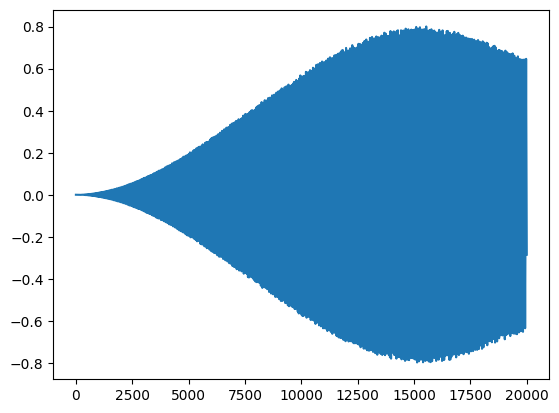

In [173]:
plt.plot(wave[:20000])

In [175]:
clock_0 = Clock(60, 44100)
oscillator_0 = Oscillator(clock_0, "sawtooth", 440)
low_pass_filter_0 = Filter(clock_0, "low-pass", notes_lut["E5"])
adsr_0 = ADSR(clock_0, 350e-3, 150e-3, 0.75, 500e-3)
objects_0 = [oscillator_0, low_pass_filter_0, adsr_0]
def waveform_function(self):
    output = self.objects[1](self.objects[0].value)*self.objects[2].value
    return output
def frequency_function(self, frequency):
    self.objects[0].frequency = frequency
def activation_function(self, activation):
    self.objects[2].active = activation
voice_0 = Voice(clock_0, objects_0, waveform_function, frequency_function, activation_function)
notes_0 = [Note("D5", 1/4, 0.5),
           Note("E5", 1/4, 0.5),
           Note("C5", 1/4, 0.5),
           Note("C4", 1/4, 0.5),
           Note("G4", 1/4, 0.5)]
bar_0 = Bar(clock_0, voice_0, None, notes_0)

clock_1 = Clock(60, 44100)
oscillator_1 = Oscillator(clock_1, "sawtooth", 440)
low_pass_filter_1 = Filter(clock_1, "low-pass", notes_lut["B4"]*3)
adsr_1 = ADSR(clock_1, 550e-3, 100e-3, 0.25, 700e-3)
objects_1 = [oscillator_1, low_pass_filter_1, adsr_1]
def waveform_function(self):
    output = self.objects[1](self.objects[0].value)*self.objects[2].value
    return output
def frequency_function(self, frequency):
    self.objects[0].frequency = frequency
def activation_function(self, activation):
    self.objects[2].active = activation
voice_1 = Voice(clock_1, objects_1, waveform_function, frequency_function, activation_function)
notes_1 = [Note("A4", 1/4, 0.5),
           Note("B4", 1/4, 0.5),
           Note("G5", 1/4, 0.5),
           Note("G4", 1/4, 0.5),
           Note("D5", 1/4, 0.5)]
bar_1 = Bar(clock_1, voice_1, None, notes_1)

wave = mix([bar_0.wave, bar_1.wave], [1, 1], 0.9)

save("test", wave, 16, clock.sample_rate)
Audio("test.wav")

In [280]:
clock = Clock()
oscillators = np.array([Oscillator(clock, "sine", frequency) for frequency in np.arange(2, 3)*440/2])
adsr = ADSR(clock, 4, 0, 1, 4)
samples = 8*clock.sample_rate
waves = np.zeros((oscillators.size, samples))
a = np.zeros(samples)
adsr.active = True
for index_sample in range(samples):
    if clock.tick_index == int(4*clock.sample_rate):
        adsr.active = False
        oscillators[0].frequency = 100
    a[index_sample] = adsr.value
    for index_oscillator, oscillator in enumerate(oscillators):
        waves[index_oscillator, index_sample] = oscillator.value#*adsr.value
    clock.tick()
adsr.active = False
wave = mix(waves, [1 for _ in range(waves.shape[0])], 0.9)
save("test", wave, 16, clock.sample_rate)
Audio("test.wav")

0
0
176400
176400


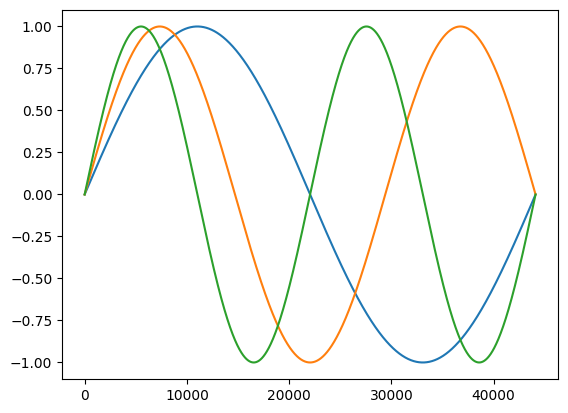

In [60]:
plt.plot(np.sin(np.linspace(0, 2/2*2*np.pi, 44100)))
plt.plot(np.sin(np.linspace(0, 3/2*2*np.pi, 44100)))
plt.plot(np.sin(np.linspace(0, 4/2*2*np.pi, 44100)))

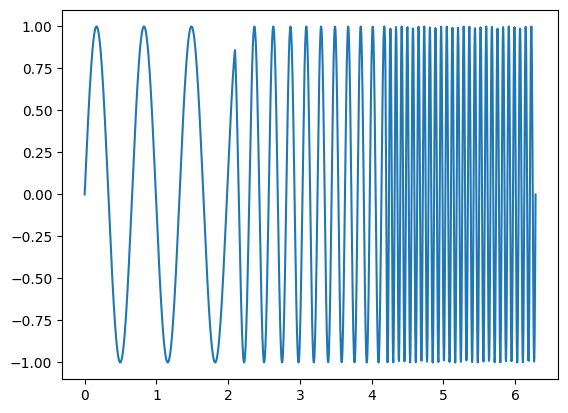

In [177]:
f = np.concatenate([np.full(500, 9.5), np.linspace(10, 20, 500), np.full(500, 80)])
x = np.linspace(0, 2*np.pi, 1500)
y = np.sin(f*x)
plt.plot(x, y)

In [84]:
def generate_symbolic_attack():
    x = sy.symbols("x")
    x_scaled = 2*x - 1
    y = -(x_scaled**3 - 3*x_scaled - 2)/4
    return sy.lambdify(x, y, "numpy")

def generate_symbolic_decay():
    x, sustain = sy.symbols("x sustain")
    x_scaled = -(2*x - 1)
    y = -((x_scaled**3 - 3*x_scaled - 2)/4)*(1 - sustain) + sustain
    return sy.lambdify((x, sustain), y, "numpy")

def generate_symbolic_release():
    x, sustain = sy.symbols("x sustain")
    x_scaled = -(2*x - 1)
    y = -((x_scaled**3 - 3*x_scaled - 2)/4)*sustain
    return sy.lambdify((x, sustain), y, "numpy")

symbolic_attack = generate_symbolic_attack()
symbolic_decay = generate_symbolic_decay()
symbolic_release = generate_symbolic_release()
# This implementation of the ADSR is different from the standard implementation. 
# Normally, the attack_duration, decay_duration and release_duration would be defined in seconds, the attack then decay would trigger when the note is pressed, the sustain would continue while the note is held and the release would trigger when the note is released.
# You don't need to change the generate_symbolic_adsr function, just change the ADSR class below. Maybe add "ratio" and "durations" arguments so you can define it either way.
# Having the release continue after the note is released will require some more work. 

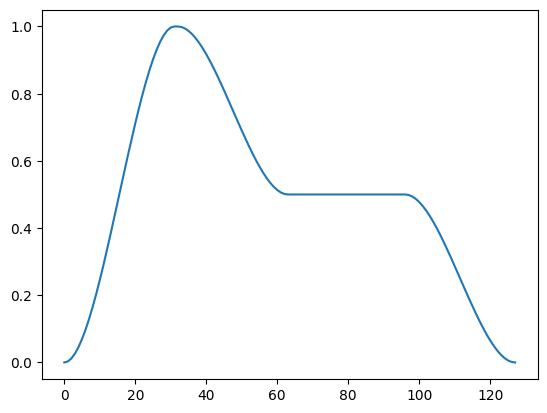

In [86]:
a = symbolic_attack(np.linspace(0, 1, 32))
d = symbolic_decay(np.linspace(0, 1, 32), 0.5)
s = np.full(32, 0.5)
r = symbolic_release(np.linspace(0, 1, 32), 0.5)
adsr = np.concatenate((a, d, s, r))
plt.plot(adsr)

In [66]:
bpm = 90
time_signature = (4, 4)
sample_rate = 44100

bar_0 = Bar(notes = ["C4", "D4", "E4", "F4"], note_values = [1/4, 1/4, 1/4, 1/4], time_signature = time_signature)
oscillators_0 = Oscillator(waveform = "sine", pitch = None, volume = 1, sample_rate = sample_rate)
adsrs_0 = ADSR(attack = 0.25, decay = 0.25, sustain = 0.25, sustain_level = 0.5, release = 0.25)
filters_0 = Filter(kernel_type = "low-pass", duration = 50e-3, width = 2, normalise = True, sample_rate = sample_rate)
wave_0 = generate_wave(bar_0, oscillators_0, adsrs_0, None, bpm, sample_rate)

# pause = generate_pause(2/4, time_signature, bpm, sample_rate)

bar_1 = Bar(notes = ["E4", "F4", "G4", "A4"], note_values = [1/4, 1/4, 1/4, 1/4], time_signature = time_signature)
oscillators_1 = Oscillator(waveform = "sine", pitch = None, volume = 1, sample_rate = sample_rate)
adsrs_1 = ADSR(attack = 0.2, decay = 0.3, sustain = 0.3, sustain_level = 0.6, release = 0.2)
filters_1 = Filter(kernel_type = "low-pass", duration = 25e-3, width = 2, normalise = True, sample_rate = sample_rate)
wave_1 = generate_wave(bar_1, oscillators_1, adsrs_1, None, bpm, sample_rate)

bar_2 = Bar(notes = ["G4", "A4", "B4", "C5"], note_values = [1/4, 1/4, 1/4, 1/4], time_signature = time_signature)
oscillators_2 = Oscillator(waveform = "sine", pitch = None, volume = 1, sample_rate = sample_rate)
adsrs_2 = ADSR(attack = 0.2, decay = 0.3, sustain = 0.3, sustain_level = 0.6, release = 0.2)
filters_2 = Filter(kernel_type = "low-pass", duration = 25e-3, width = 2, normalise = True, sample_rate = sample_rate)
wave_2 = generate_wave(bar_2, oscillators_2, adsrs_2, None, bpm, sample_rate)

wave = mix((wave_0, wave_1, wave_2), (0.75, 0.5, 0.25), 0.5)

save("test", wave, 16, sample_rate)
Audio("test.wav")

# figure, axes = plt.subplots(3, 2, figsize = (8, 12), layout = "constrained")
# axes[0, 0].plot(np.linspace(0, 1, sample_rate), adsrs_0.apply(np.ones(sample_rate)))
# axes[0, 1].plot(np.linspace(0, filters_0.duration, filters_0.kernel.size), filters_0.kernel)
# axes[1, 0].plot(np.linspace(0, 1, sample_rate), adsrs_1.apply(np.ones(sample_rate)))
# axes[1, 1].plot(np.linspace(0, filters_0.duration, filters_1.kernel.size), filters_1.kernel)
# axes[2, 0].plot(np.linspace(0, 1, sample_rate), adsrs_2.apply(np.ones(sample_rate)))
# axes[2, 1].plot(np.linspace(0, filters_2.duration, filters_2.kernel.size), filters_2.kernel)

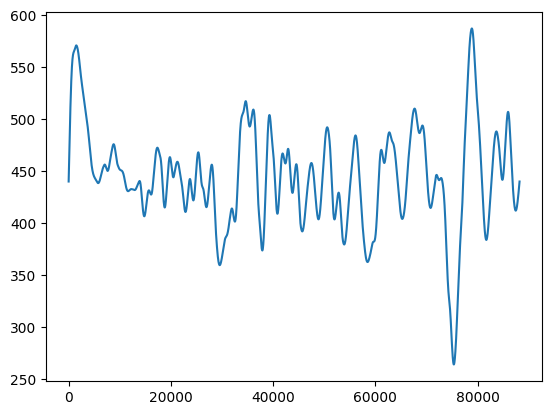

In [63]:
from noise import pnoise1
n = np.array([440*(pnoise1(index, octaves = 3)/2 + 1) for index in np.linspace(0, 16, int(sample_rate*duration))])
plt.plot(n)

175


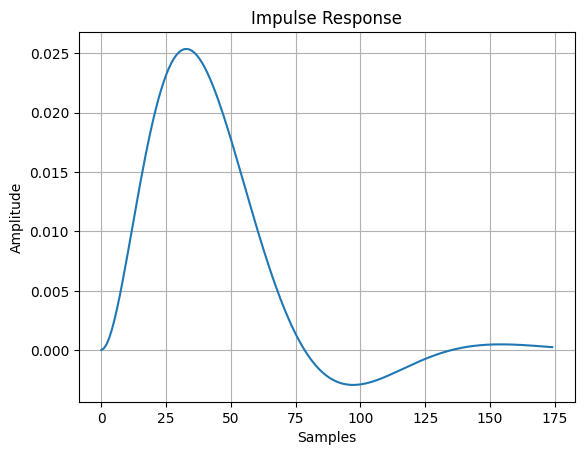

In [220]:
# Real-time low-pass filter

from scipy.signal import butter, lfilter

sample_rate = 44100
duration = 2
frequency = 440
cutoff_frequency = 440
order = 3

b, a = butter(order, cutoff_frequency, btype = "lowpass", fs = sample_rate)
threshold = 0.01
impulse = np.zeros(int(sample_rate*order*2/cutoff_frequency))
impulse[0] = 1
impulse_response = lfilter(b, a, impulse)
buffer_samples = impulse_response.size - np.argwhere(np.abs(impulse_response[::-1]) > threshold*impulse_response.max())[0, 0]
print(buffer_samples)
buffer_duration = buffer_samples/sample_rate

plt.plot(impulse_response[0:buffer_samples])
plt.title("Impulse Response")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

from noise import pnoise1
n = np.array([pnoise1(index, octaves = 3)/2 + 1 for index in np.linspace(0, 16, int(sample_rate*duration))])

samples = square_wave(frequency*np.linspace(0, duration*2*np.pi, int(sample_rate*duration)))
samples_filtered = np.zeros_like(samples)
buffer = []
for index in range(samples.size):
    buffer.append(samples[index])
    # buffer = samples[start:end]
    # print(buffer[-np.min([buffer_samples, len(buffer) - 1]):])
    buffer_filtered = lfilter(b, a, buffer[-np.min([buffer_samples, len(buffer) - 1]):])
    samples_filtered[index] = buffer_filtered[-1]
    # buffer[:-1] = buffer[1:]

In [217]:
a = [1, 2, 3, 4, 5]
print(a[-1:])

[5]


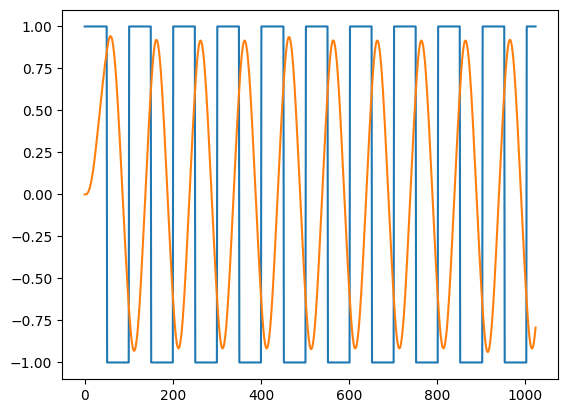

In [221]:
plt.plot(samples[:1024])
plt.plot(samples_filtered[:1024])

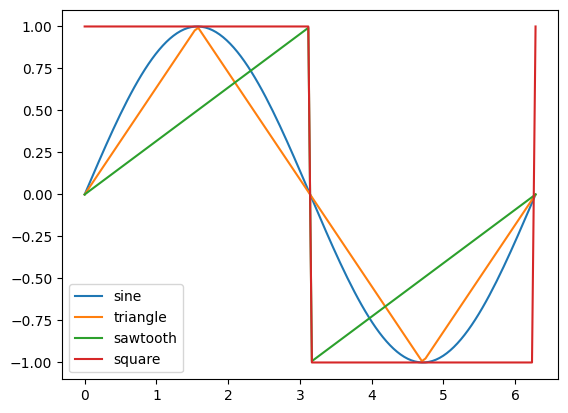

In [187]:
def generate_triangle_wave():
    x, p = sy.symbols("x"), 2*sy.pi
    y = (4/p)*sy.Abs(sy.Mod(x - p/4, p) - p/2) - 1
    return sy.lambdify(x, y, "numpy")

def generate_sawtooth_wave():
    x, p = sy.symbols("x"), 2*sy.pi
    y = 2*(x/p - sy.floor(1/2 + x/p))
    return sy.lambdify(x, y, "numpy")

def generate_square_wave():
    x, p = sy.symbols("x"), 2*sy.pi
    y = (-1)**sy.floor(2*x/p)
    return sy.lambdify(x, y, "numpy")

triangle_wave = generate_triangle_wave()
sawtooth_wave = generate_sawtooth_wave()
square_wave = generate_square_wave()

amplitude, frequency, phase = 1, 1, 0

x = np.linspace(0, 2*np.pi, 128)
plt.plot(x, amplitude*np.sin(frequency*x + phase), label = "sine")
plt.plot(x, amplitude*triangle_wave(frequency*x + phase), label = "triangle")
plt.plot(x, amplitude*sawtooth_wave(frequency*x + phase), label = "sawtooth")
plt.plot(x, amplitude*square_wave(frequency*x + phase), label = "square")
plt.legend()